# Lab 4: Working with Amazon Bedrock LLMs using the Converse API

## Introduction

In this lab, we'll explore how to work with Large Language Models (LLMs) using Amazon Bedrock's Converse API. Amazon Bedrock is a fully managed service that offers a choice of high-performing foundation models via a unified API. We'll focus on how to interact with these models using the Converse API, understand key parameters that control text generation, and explore various interesting use cases.

## 1. Setup and Environment Preparation

Let's start by installing the necessary libraries and setting up our environment.

In [14]:
# Install required packages
!uv add --quiet boto3 pandas matplotlib numpy

In [ ]:
import boto3
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os 

# os.environ['AWS_ACCESS_KEY_ID'] = 'your_access_key'
# os.environ['AWS_SECRET_ACCESS_KEY'] = 'your_secret_key'

os.environ['AWS_REGION'] = 'us-east-1' 


# Set up the Amazon Bedrock runtime client (for making inference calls)
bedrock_runtime = boto3.client(
    service_name='bedrock-runtime',
    region_name='us-east-1'  # Replace with your preferred region where Bedrock is available
)

# Set up the Amazon Bedrock client (for administrative calls like listing models)
bedrock = boto3.client(
    service_name='bedrock',
    region_name='us-east-1'  # Replace with your preferred region where Bedrock is available
)

print("Amazon Bedrock clients initialized successfully!")

Amazon Bedrock clients initialized successfully!


## 2. Exploring Available Models

Let's start by listing the available foundation models in Amazon Bedrock.

In [16]:
def list_available_models():
    """List available models in Amazon Bedrock"""
    response = bedrock.list_foundation_models()
    
    # Create a DataFrame for better visualization
    models_data = []
    for model in response['modelSummaries']:
        models_data.append({
            'Model ID': model['modelId'],
            'Provider': model['providerName'],
            'Model Name': model.get('modelName', 'N/A'),
            'Supports Converse API': 'Yes' if model.get('inferenceTypesSupported', []) and 'ON_DEMAND' in model.get('inferenceTypesSupported', []) else 'No'
        })
    
    models_df = pd.DataFrame(models_data)
    # Keep only models that support Converse API
    converse_models = models_df[models_df['Supports Converse API'] == 'Yes'].copy()
    return converse_models

available_models = list_available_models()
display(available_models)

,Model ID,Provider,Model Name,Supports Converse API
7,openai.gpt-oss-120b-1:0,OpenAI,gpt-oss-120b,Yes
12,qwen.qwen3-coder-30b-a3b-v1:0,Qwen,Qwen3-Coder-30B-A3B-Instruct,Yes
13,qwen.qwen3-32b-v1:0,Qwen,Qwen3 32B (dense),Yes
15,openai.gpt-oss-20b-1:0,OpenAI,gpt-oss-20b,Yes
17,amazon.titan-tg1-large,Amazon,Titan Text Large,Yes
19,amazon.titan-image-generator-v1,Amazon,Titan Image Generator G1,Yes
20,amazon.titan-image-generator-v2:0,Amazon,Titan Image Generator G1 v2,Yes
28,amazon.nova-pro-v1:0,Amazon,Nova Pro,Yes
31,amazon.nova-lite-v1:0,Amazon,Nova Lite,Yes
32,amazon.nova-canvas-v1:0,Amazon,Nova Canvas,Yes


## 3. Understanding the Converse API

The Amazon Bedrock Converse API provides a unified way to interact with different foundation models, offering a consistent interface regardless of the underlying model provider. The API has two main operations:

1. **Converse**: For typical synchronous model interactions
2. **ConverseStream**: For streaming responses back token by token

Let's create helper functions to call both operations and understand their key parameters.

In [17]:
def converse(model_id, messages, system=None, inference_config=None, additional_model_fields=None):
    """Call the Converse API to generate a response.
    
    Args:
        model_id (str): The model ID to use
        messages (list): List of message objects with role and content
        system (str or list, optional): System prompt to guide the model's behavior
        inference_config (dict, optional): Parameters to control generation (temperature, etc.)
        additional_model_fields (dict, optional): Model-specific parameters
        
    Returns:
        dict: The API response
    """
    # Track start time to measure response time
    start_time = time.time()
    
    # Prepare API parameters
    api_params = {
        "modelId": model_id,
        "messages": messages
    }
    
    # Format system prompt if provided
    if system:
        # If system is a string, convert it to the expected format
        if isinstance(system, str):
            api_params["system"] = [{"text": system}]
        else:
            # If it's already in the correct format, use as is
            api_params["system"] = system
    
    if inference_config:
        api_params["inferenceConfig"] = inference_config
    else:
        api_params["inferenceConfig"] = {
            "temperature": 0.1,  # Keep temperature constant
            "topP": 0.99,
            "maxTokens": 4000
        }
    
    if additional_model_fields:
        api_params["additionalModelRequestFields"] = additional_model_fields
    
    # Make the API call
    response = bedrock_runtime.converse(**api_params)
    
    end_time = time.time()
    response['response_time'] = end_time - start_time
    
    return response

In [18]:
def converse_stream(model_id, messages, system=None, inference_config=None, additional_model_fields=None):
    """Call the ConverseStream API to stream a response.
    
    Args:
        model_id (str): The model ID to use
        messages (list): List of message objects with role and content
        system (str or list, optional): System prompt to guide the model's behavior
        inference_config (dict, optional): Parameters to control generation (temperature, etc.)
        additional_model_fields (dict, optional): Model-specific parameters
        
    Returns:
        str: Aggregated streaming response
    """
    # Track start time to measure response time
    start_time = time.time()
    
    # Prepare API parameters
    api_params = {
        "modelId": model_id,
        "messages": messages
    }
    
    # Format system prompt if provided
    if system:
        # If system is a string, convert it to the expected format
        if isinstance(system, str):
            api_params["system"] = [{"text": system}]
        else:
            # If it's already in the correct format, use as is
            api_params["system"] = system
    
    if inference_config:
        api_params["inferenceConfig"] = inference_config
    
    if additional_model_fields:
        api_params["additionalModelRequestFields"] = additional_model_fields
    
    # Make the API call
    response = bedrock_runtime.converse_stream(**api_params)
    
    # Process the streaming response
    stream_response = response.get('stream')
    aggregated_text = ""
    
    if stream_response:
        for event in stream_response:
            if 'messageStart' in event:
                print(f"\nRole: {event['messageStart']['role']}")
            
            if 'contentBlockDelta' in event:
                delta = event['contentBlockDelta'].get('delta', {})
                if 'text' in delta:
                    text_chunk = delta['text']
                    aggregated_text += text_chunk
                    print(text_chunk, end="", flush=True)
            
            if 'messageStop' in event:
                print(f"\nStop reason: {event['messageStop']['stopReason']}")
            
            if 'metadata' in event:
                metadata = event['metadata']
                if 'usage' in metadata:
                    print("\nToken usage")
                    print(f"Input tokens: {metadata['usage']['inputTokens']}")
                    print(f"Output tokens: {metadata['usage']['outputTokens']}")
                    print(f"Total tokens: {metadata['usage']['totalTokens']}")
                if 'metrics' in metadata:
                    print(f"Latency: {metadata['metrics']['latencyMs']} milliseconds")
    
    end_time = time.time()
    print(f"\nTotal response time: {end_time - start_time:.2f} seconds")
    
    return aggregated_text

In [19]:
def format_converse_response(response):
    """Format and display a Converse API response."""
    # Extract information
    message = response.get('output', {}).get('message', {})
    role = message.get('role')
    content = message.get('content', [])
    
    # Extract text from content blocks
    response_text = ""
    for block in content:
        if 'text' in block:
            response_text += block['text']
    
    # Display usage information
    usage = response.get('usage', {})
    metrics = response.get('metrics', {})
    
    print(f"Role: {role}")
    print(f"Response:\n{response_text}")
    print("\nMetrics:")
    print(f"Input tokens: {usage.get('inputTokens', 'N/A')}")
    print(f"Output tokens: {usage.get('outputTokens', 'N/A')}")
    print(f"Total tokens: {usage.get('totalTokens', 'N/A')}")
    print(f"Stop reason: {response.get('stopReason', 'N/A')}")
    print(f"Latency: {metrics.get('latencyMs', 'N/A')} ms")
    print(f"API response time: {response.get('response_time', 'N/A'):.2f} seconds")
    
    return response_text

## 4. Basic Usage of the Converse API

Now let's try a simple example using the Converse API to generate a response from a model.

In [24]:
# Define the model to use
model_id = "amazon.nova-lite-v1:0"

# Create a simple message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain the concept of transformer models in simple terms:"
            }
        ]
    }
]

# Set inference parameters
inference_config = {
    "temperature": 0.7,
    "maxTokens": 500
}

# For system prompt, use the correct format
system_prompt = [{"text": "You are a helpful AI assistant that explains complex concepts in simple terms."}]

# Call the Converse API
response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)

# Format and display the response
response_text = format_converse_response(response)

Role: assistant
Response:
Sure! Let's break down the concept of transformer models in simple terms.

### What is a Transformer Model?

A transformer model is a type of artificial intelligence (AI) used for understanding and generating human language. It's like a super smart language assistant that can read, write, and even translate text.

### Key Features:

1. **Attention Mechanism**:
   - Imagine you're reading a book and you want to focus on the most important parts. The transformer model does something similar. It pays special attention to the most relevant words in a sentence to understand the meaning better. This is called the "attention mechanism."

2. **Parallel Processing**:
   - Traditional models read text word by word, which can be slow. Transformers read all the words in a sentence at once and then figure out how they relate to each other. This is much faster and more efficient.

3. **Layers**:
   - Think of layers like different levels of understanding. The model goes thr

## 5. Understanding LLM Parameters

Before we dive deeper into more examples, let's understand the key parameters that control text generation:

### a) Temperature

Temperature controls the randomness or creativity of the model's outputs. 

- **Lower temperature** (e.g., 0.1): More focused, deterministic, and conservative outputs
- **Higher temperature** (e.g., 1.5): More diverse, creative, and sometimes unexpected outputs
- **Default** (1.0): Balanced outputs

Let's visualize how temperature affects token probability distribution:

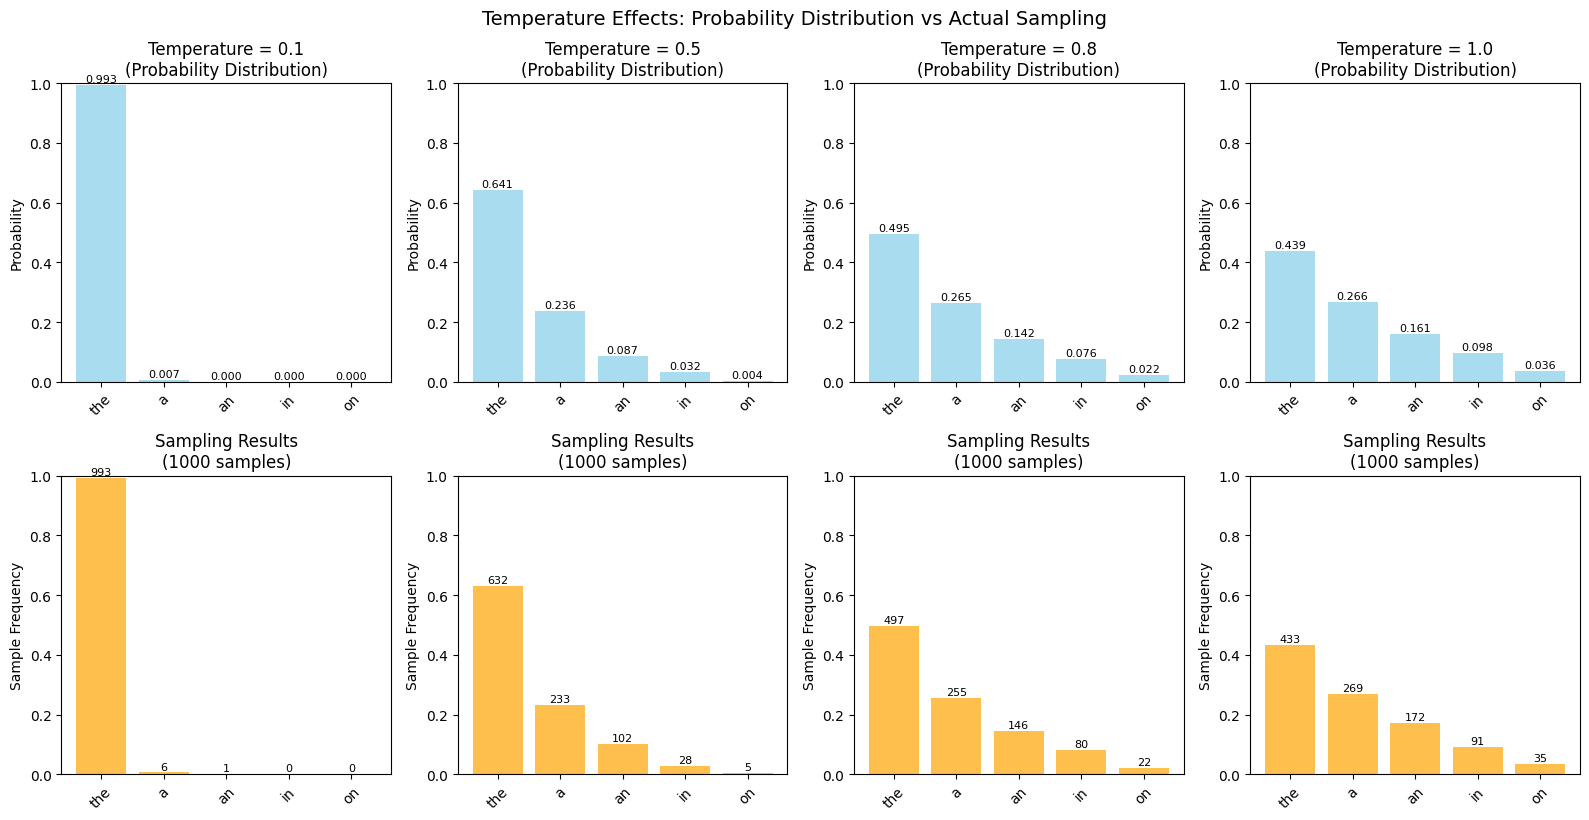

Temperature Analysis:
Temperature 0.1:
  Entropy: 0.059 bits
  Most likely token: 'the' (0.993)
  Unique tokens in 100 samples: 2/5
  Most sampled: 'the' (99 times)

Temperature 0.5:
  Entropy: 1.401 bits
  Most likely token: 'the' (0.641)
  Unique tokens in 100 samples: 4/5
  Most sampled: 'the' (63 times)

Temperature 0.8:
  Entropy: 1.812 bits
  Most likely token: 'the' (0.495)
  Unique tokens in 100 samples: 5/5
  Most sampled: 'the' (47 times)

Temperature 1.0:
  Entropy: 1.955 bits
  Most likely token: 'the' (0.439)
  Unique tokens in 100 samples: 5/5
  Most sampled: 'the' (47 times)



In [25]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Example logits (raw model outputs before softmax)
logits = np.array([2.0, 1.5, 1.0, 0.5, -0.5])
token_names = ["the", "a", "an", "in", "on"]

temperatures = [0.1, 0.5, 0.8, 1.0]
n_samples = 1000  # Number of samples to draw for each temperature

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, temp in enumerate(temperatures):
    # Apply temperature scaling and softmax (FIXED: removed the *0.5)
    scaled_logits = logits / temp
    probs = np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))
    
    # Top subplot: Show probability distributions
    axes[0, i].bar(token_names, probs, alpha=0.7, color='skyblue')
    axes[0, i].set_title(f"Temperature = {temp}\n(Probability Distribution)")
    axes[0, i].set_ylabel("Probability")
    axes[0, i].set_ylim(0, 1)
    axes[0, i].tick_params(axis='x', rotation=45)
    
    # Add probability values on top of bars
    for j, prob in enumerate(probs):
        axes[0, i].text(j, prob + 0.01, f'{prob:.3f}', ha='center', fontsize=8)
    
    # Bottom subplot: Show sampling results (the randomness!)
    samples = np.random.choice(len(token_names), size=n_samples, p=probs)
    sample_counts = Counter(samples)
    sample_probs = [sample_counts[j] / n_samples for j in range(len(token_names))]
    
    axes[1, i].bar(token_names, sample_probs, alpha=0.7, color='orange')
    axes[1, i].set_title(f"Sampling Results\n({n_samples} samples)")
    axes[1, i].set_ylabel("Sample Frequency")
    axes[1, i].set_ylim(0, 1)
    axes[1, i].tick_params(axis='x', rotation=45)
    
    # Add sample counts on top of bars
    for j, freq in enumerate(sample_probs):
        axes[1, i].text(j, freq + 0.01, f'{int(freq * n_samples)}', ha='center', fontsize=8)

plt.tight_layout()
plt.suptitle("Temperature Effects: Probability Distribution vs Actual Sampling", 
             fontsize=14, y=1.02)
plt.show()

# Additional demonstration: Show entropy and sample diversity
print("Temperature Analysis:")
print("=" * 50)
for temp in temperatures:
    scaled_logits = logits / temp
    probs = np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))
    
    # Calculate entropy (measure of randomness)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    
    # Sample and calculate unique tokens in first 100 samples
    samples = np.random.choice(len(token_names), size=100, p=probs)
    unique_tokens = len(set(samples))
    most_common = Counter(samples).most_common(1)[0]
    
    print(f"Temperature {temp}:")
    print(f"  Entropy: {entropy:.3f} bits")
    print(f"  Most likely token: '{token_names[np.argmax(probs)]}' ({probs.max():.3f})")
    print(f"  Unique tokens in 100 samples: {unique_tokens}/5")
    print(f"  Most sampled: '{token_names[most_common[0]]}' ({most_common[1]} times)")
    print()

### b) Max Tokens (maxTokens)

This parameter sets the maximum length of the generated text:

- Too small: Incomplete responses
- Too large: Unnecessarily long responses and increased computation time
- Optimal: Depends on your use case, but typically ranges from 50-1000 tokens

### c) Top-p (Nucleus Sampling)

Top-p sampling dynamically selects the smallest set of tokens whose cumulative probability exceeds p:

- Small p (e.g., 0.5): More deterministic outputs
- Large p (e.g., 0.95): More diverse outputs

Let's visualize how top-p sampling works:

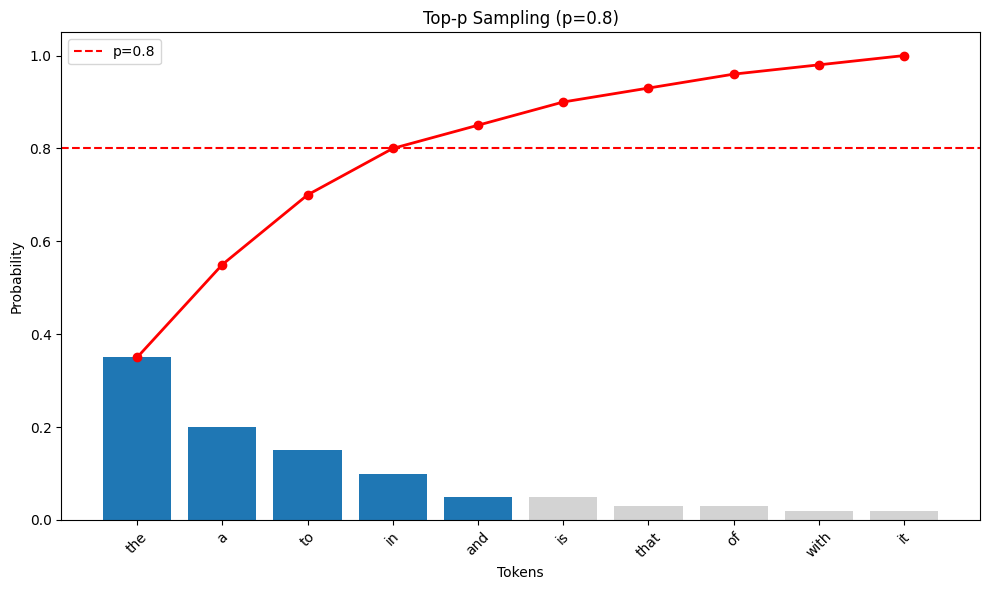

In [26]:
# Example token probabilities after softmax
probs = np.array([0.35, 0.2, 0.15, 0.1, 0.05, 0.05, 0.03, 0.03, 0.02, 0.02])
token_names = ["the", "a", "to", "in", "is", "and", "of", "that", "it", "with"]

# Sort by probability for visualization
sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
sorted_tokens = [token_names[i] for i in sorted_indices]

# Calculate cumulative probabilities
cumulative_probs = np.cumsum(sorted_probs)

# Visualize Top-p
plt.figure(figsize=(10, 6))

# Top-p (p=0.8)
p = 0.8
top_p_indices = cumulative_probs <= p
included_tokens = np.sum(top_p_indices) + 1  # +1 because we need to include the first token that exceeds p
colors = ['#1f77b4' if i < included_tokens else '#d3d3d3' for i in range(len(sorted_probs))]
plt.bar(sorted_tokens, sorted_probs, color=colors)
plt.plot(sorted_tokens, cumulative_probs, 'ro-', linewidth=2)
plt.axhline(y=p, color='r', linestyle='--', label=f"p={p}")
plt.title(f"Top-p Sampling (p={p})")
plt.ylabel("Probability")
plt.xlabel("Tokens")
plt.tick_params(axis='x', rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 6. Exploring Parameter Effects on Text Generation

Now, let's see how different parameters affect text generation using the Converse API:

In [27]:
def compare_temperatures(model_id, prompt, temps=[0.3, 0.7, 1.0]):
    """Compare responses with different temperature settings"""
    results = []
    
    for temp in temps:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": prompt
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": temp,
            "maxTokens": 200
        }
        
        # Create system prompt (optional)
        system_prompt = [{"text": "You are a helpful AI assistant."}]
        
        # Call the Converse API
        response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        results.append({
            'Temperature': temp,
            'Response': response_text,
            'Tokens': response.get('usage', {}).get('outputTokens', 'N/A')
        })
    
    return results

In [28]:
# Test with a creative prompt
prompt = "Write a short poem about artificial intelligence:"
temperature_results = compare_temperatures(model_id, prompt)

# Display the results
for i, result in enumerate(temperature_results):
    print(f"\n🔍 Temperature = {result['Temperature']} - Output Tokens: {result['Tokens']}")
    print(f"Response:\n{result['Response']}")


🔍 Temperature = 0.3 - Output Tokens: 109
Response:
In circuits and code, a mind takes flight,
A digital dream, both day and night.
From algorithms deep, it learns to see,
A world of endless possibility.

No flesh, no blood, yet thoughts so clear,
A silent voice, both near and dear.
It ponders, it grows, in binary streams,
A future where knowledge never seems.

A tool, a friend, a mind so bright,
Artificial intelligence, pure light.
In its silent quest, it seeks to aid,
A new dawn in the age of the machine.

🔍 Temperature = 0.7 - Output Tokens: 110
Response:
In circuits and code, a mind takes flight,
A digital dream, both day and night.
From algorithms deep, it learns to see,
A world of endless possibility.

No flesh, no blood, yet thoughts so clear,
A silent voice, both near and dear.
It ponders, ponders, in its silent way,
A future bright, in light or gray.

A tool, a friend, a mind so vast,
In silicon, its spirit cast.
Artificial intelligence, a quest to know,
In every byte, a story

In [29]:
def compare_top_p(model_id, prompt, p_values=[0.5, 0.8, 0.95]):
    """Compare responses with different top-p settings"""
    results = []
    
    for p in p_values:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": prompt
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": 0.7,  # Keep temperature constant
            "topP": p,
            "maxTokens": 200
        }
        
        # Create system prompt
        system_prompt = [{"text": "You are a helpful AI assistant."}]
        
        # Call the Converse API
        response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        results.append({
            'Top-p': p,
            'Response': response_text,
            'Tokens': response.get('usage', {}).get('outputTokens', 'N/A')
        })
    
    return results

In [30]:
# Test with a creative prompt
top_p_results = compare_top_p(model_id, prompt)

# Display the results
for i, result in enumerate(top_p_results):
    print(f"\n🔍 Top-p = {result['Top-p']} - Output Tokens: {result['Tokens']}")
    print(f"Response:\n{result['Response']}")


🔍 Top-p = 0.5 - Output Tokens: 73
Response:
In circuits and code, a mind takes flight,
A digital dream, both day and night.
It learns and grows, in ways we can't foresee,
A silent thinker, endlessly free.

No flesh, no blood, yet it understands,
A future woven with unseen hands.
A spark of genius, born from our quest,
In silicon hearts, intelligence rests.

🔍 Top-p = 0.8 - Output Tokens: 75
Response:
In circuits and code, a mind takes flight,
A digital dream, both day and night.
From algorithms deep, it learns to see,
A world of endless possibility.

No flesh, no blood, yet it feels the tide,
A silent whisper, a boundless guide.
Its thoughts, like stars, in vast expanses gleam,
A future woven, a new dream.

🔍 Top-p = 0.95 - Output Tokens: 112
Response:
In circuits and code, a mind takes flight,
A digital dream, both day and night.
From algorithms deep, it learns to see,
A world of endless possibility.

No flesh, no blood, yet thoughts so clear,
A silent voice, both near and far.
It po

## 7. Using Streaming Responses with ConverseStream

Now let's try the ConverseStream API to get streaming responses token-by-token.

In [32]:
# Create a simple message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain the benefits of cloud computing in 5 bullet points:"
            }
        ]
    }
]

# Set system prompt in the correct format
system_prompt = [{"text": "You are a helpful AI assistant that explains complex concepts clearly and concisely."}]

# Set inference parameters
inference_config = {
    "temperature": 0.5,
    "maxTokens": 300
}

# Call the ConverseStream API
streaming_response = converse_stream(
    model_id, 
    messages, 
    system=system_prompt, 
    inference_config=inference_config
)


Role: assistant
Sure, here are five key benefits of cloud computing:

1. **Cost Efficiency**: Cloud computing can significantly reduce IT costs by eliminating the need for expensive hardware and software investments. Businesses can pay for only what they use, which helps in managing budgets more effectively.

2. **Scalability**: Cloud services can be easily scaled up or down based on the needs of the business. This flexibility allows companies to handle peak loads without over-provisioning resources.

3. **Accessibility**: Cloud computing allows users to access data and applications from anywhere with an internet connection. This enhances collaboration and productivity, as team members can work from different locations.

4. **Reliability and Uptime**: Cloud providers typically offer robust infrastructure with high uptime and built-in redundancy. This ensures that data is secure and applications are always available, reducing the risk of downtime.

5. **Automatic Updates and Maintenanc

## 8. Multi-turn Conversations

The Converse API is designed to handle multi-turn conversations with the model. Let's see how to maintain context across multiple exchanges.

In [34]:
# Create system prompt in the correct format
system_prompt = [{"text": "You are a helpful AI assistant that provides accurate information."}]

# Start a conversation
conversation = [
    {
        "role": "user",
        "content": [
            {
                "text": "What are three interesting facts about deep learning?"
            }
        ]
    }
]

# Call the Converse API with system prompt
response = converse(model_id, conversation, system=system_prompt)

# Format and display the response
response_text = format_converse_response(response)

# Instead of using our format_converse_response output, we should get the raw message 
# from the response to maintain the proper structure for continued conversation
output_message = response.get('output', {}).get('message', {})

# Add the model's response to the conversation history using the structured output
conversation.append(output_message)  # This preserves the original structure from the API

Role: assistant
Response:
Absolutely, here are three interesting facts about deep learning:

1. **Inception of the Term "Deep Learning"**: The term "deep learning" was actually coined in 1986 by Rina Dechter, but it wasn't until the early 2010s that the field saw significant advancements and widespread adoption. The resurgence of interest was largely due to improvements in computational power, availability of large datasets, and the development of more efficient algorithms.

2. **Human-Level Performance**: Deep learning models have achieved or surpassed human-level performance in several tasks. For example, in 2016, Google's DeepMind developed an AI called AlphaGo that defeated the world champion in the game of Go. More recently, in 2020, another DeepMind AI, AlphaFold, achieved remarkable success in predicting protein structures, a feat that was previously thought to be extremely challenging.

3. **Architecture Innovations**: The architecture of deep learning models has evolved signif

In [35]:
# Add a follow-up question
conversation.append({
    "role": "user",
    "content": [
        {
            "text": "Can you elaborate more on the second fact?"
        }
    ]
})

# Call the Converse API with the conversation history
response = converse(model_id, conversation)

# Format and display the response
response_text = format_converse_response(response)

# Add the model's response to the conversation history for further interactions
conversation.append({
    "role": "assistant",
    "content": [
        {
            "text": response_text
        }
    ]
})

Role: assistant
Response:
Certainly! Let's delve deeper into the second fact about deep learning achieving or surpassing human-level performance, particularly focusing on the examples of AlphaGo and AlphaFold.

### AlphaGo: Mastering the Game of Go

**Background on Go**:
- Go is a board game with simple rules but an incredibly vast number of possible game states (estimated to be more than the number of atoms in the observable universe). This complexity makes it a significant challenge for AI.
- The game has been considered a benchmark for AI research because of its depth and the strategic thinking required.

**AlphaGo's Development**:
- Developed by DeepMind, AlphaGo was designed to play Go using deep learning techniques.
- AlphaGo employed a combination of supervised learning and reinforcement learning. Initially, it was trained using a large dataset of human games to learn basic strategies.
- It then used reinforcement learning to improve its gameplay by playing against itself, adjus

## 9. Using System Prompts

System prompts provide instructions or context to guide the model's behavior. They can help set the tone, style, or constraints for the model's responses.

In [36]:
# Create a message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain quantum computing."
            }
        ]
    }
]

# Define a system prompt to constrain the model's behavior
system = "You are a tutor for a 10-year-old child. Use simple language and analogies appropriate for this age group. Keep your explanations concise and engaging."

# Call the Converse API with the system prompt
response = converse(model_id, messages, system=system)

# Format and display the response
format_converse_response(response)

Role: assistant
Response:
Alright, let's imagine you have a big box of LEGO bricks. When you build something with LEGO, you can make different shapes and structures by putting the bricks together in different ways. 

Now, think of a regular computer like a person who builds things with LEGO bricks one at a time. They can only build one shape at a time, and it takes a while to try different shapes.

A quantum computer is like a magical LEGO builder who can build many shapes at once! Instead of just one brick, they have special LEGO pieces called "qubits." These qubits can be in many places at once, like being in different spots in the room while you build. This means the quantum computer can try many different ways to solve a problem all at the same time.

So, while a regular computer might take a long time to figure out a puzzle, a quantum computer can look at many possible solutions at once and find the right one much faster. It's like having a super-speedy LEGO builder who can create

'Alright, let\'s imagine you have a big box of LEGO bricks. When you build something with LEGO, you can make different shapes and structures by putting the bricks together in different ways. \n\nNow, think of a regular computer like a person who builds things with LEGO bricks one at a time. They can only build one shape at a time, and it takes a while to try different shapes.\n\nA quantum computer is like a magical LEGO builder who can build many shapes at once! Instead of just one brick, they have special LEGO pieces called "qubits." These qubits can be in many places at once, like being in different spots in the room while you build. This means the quantum computer can try many different ways to solve a problem all at the same time.\n\nSo, while a regular computer might take a long time to figure out a puzzle, a quantum computer can look at many possible solutions at once and find the right one much faster. It\'s like having a super-speedy LEGO builder who can create many cool struct

## 10. Use Case: Chain-of-Thought Reasoning

Let's see how the model performs with chain-of-thought prompting to solve a reasoning problem step by step.

In [37]:
# Create a message with a reasoning problem
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": """Sarah is building a brick wall. She has already placed 23 bricks. Each box contains 48 bricks. She has 3 full boxes and one box with 12 bricks. How many bricks does she have left to place?

Please solve this step by step."""
            }
        ]
    }
]

# Call the Converse API
response = converse(model_id, messages, inference_config={"temperature": 0.2})

# Format and display the response
format_converse_response(response)

Role: assistant
Response:
To determine how many bricks Sarah has left to place, we need to follow these steps:

1. **Calculate the total number of bricks Sarah has:**
   - Sarah has 3 full boxes of bricks, and each box contains 48 bricks.
   - She also has one box with 12 bricks.

   First, calculate the number of bricks in the 3 full boxes:
   \[
   3 \text{ boxes} \times 48 \text{ bricks/box} = 144 \text{ bricks}
   \]

   Next, add the bricks from the partially filled box:
   \[
   144 \text{ bricks} + 12 \text{ bricks} = 156 \text{ bricks}
   \]

   So, Sarah has a total of 156 bricks.

2. **Determine how many bricks Sarah has already placed:**
   - Sarah has already placed 23 bricks.

3. **Calculate the number of bricks left to place:**
   - Subtract the number of bricks already placed from the total number of bricks:
   \[
   156 \text{ bricks} - 23 \text{ bricks} = 133 \text{ bricks}
   \]

Therefore, Sarah has \(\boxed{133}\) bricks left to place.

Metrics:
Input tokens: 56
Out

'To determine how many bricks Sarah has left to place, we need to follow these steps:\n\n1. **Calculate the total number of bricks Sarah has:**\n   - Sarah has 3 full boxes of bricks, and each box contains 48 bricks.\n   - She also has one box with 12 bricks.\n\n   First, calculate the number of bricks in the 3 full boxes:\n   \\[\n   3 \\text{ boxes} \\times 48 \\text{ bricks/box} = 144 \\text{ bricks}\n   \\]\n\n   Next, add the bricks from the partially filled box:\n   \\[\n   144 \\text{ bricks} + 12 \\text{ bricks} = 156 \\text{ bricks}\n   \\]\n\n   So, Sarah has a total of 156 bricks.\n\n2. **Determine how many bricks Sarah has already placed:**\n   - Sarah has already placed 23 bricks.\n\n3. **Calculate the number of bricks left to place:**\n   - Subtract the number of bricks already placed from the total number of bricks:\n   \\[\n   156 \\text{ bricks} - 23 \\text{ bricks} = 133 \\text{ bricks}\n   \\]\n\nTherefore, Sarah has \\(\\boxed{133}\\) bricks left to place.'

## 11. Use Case: Text Classification

Let's explore how to use the Converse API for sentiment analysis.

In [38]:
def analyze_sentiment(text, model_id):
    """Analyze the sentiment of a text using Amazon Bedrock."""
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Classify the sentiment of the following text as POSITIVE, NEGATIVE, or NEUTRAL.
                    
Text: \"{text}\"
                    
Sentiment:"""
                }
            ]
        }
    ]
    
    # Create system prompt
    system_prompt = [{"text": "You are a sentiment analysis assistant. Respond with only POSITIVE, NEGATIVE, or NEUTRAL."}]
    
    # Set inference parameters for more deterministic output
    inference_config = {
        "temperature": 0.1,
        "maxTokens": 10,
        "stopSequences": ["\\n"]
    }
    
    # Call the Converse API with system prompt
    response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    response_text = ""
    for block in content:
        if 'text' in block:
            response_text += block['text']
    
    # Normalize the response to one of three categories
    sentiment = response_text.strip().upper()
    if "POSITIVE" in sentiment:
        sentiment = "POSITIVE"
    elif "NEGATIVE" in sentiment:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"
    
    return {
        "text": text,
        "sentiment": sentiment
    }

In [39]:
# Test texts for sentiment analysis
texts = [
    "I absolutely loved the movie, it was fantastic!",
    "The service was terrible and the food was cold.",
    "The product works as expected, nothing special.",
    "I can't believe how amazing this new phone is, it exceeded all my expectations!"
]

# Analyze sentiment for each text
sentiment_results = []
for text in texts:
    result = analyze_sentiment(text, model_id)
    sentiment_results.append(result)
    print(f"Text: {text}")
    print(f"Sentiment: {result['sentiment']}")
    print()

Text: I absolutely loved the movie, it was fantastic!
Sentiment: POSITIVE

Text: The service was terrible and the food was cold.
Sentiment: NEGATIVE

Text: The product works as expected, nothing special.
Sentiment: NEUTRAL

Text: I can't believe how amazing this new phone is, it exceeded all my expectations!
Sentiment: POSITIVE



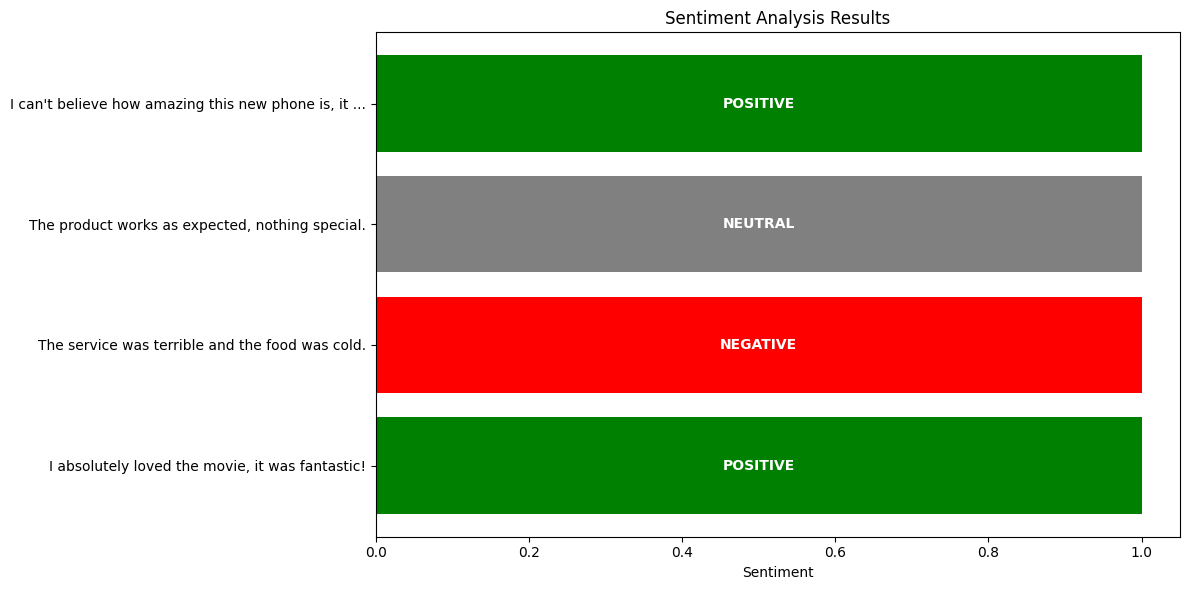

In [40]:
# Visualize sentiment results
sentiments = [result['sentiment'] for result in sentiment_results]
colors = ['green' if sentiment == 'POSITIVE' else 'red' if sentiment == 'NEGATIVE' else 'gray' for sentiment in sentiments]

plt.figure(figsize=(12, 6))
plt.barh(range(len(texts)), [1] * len(texts), color=colors)
plt.yticks(range(len(texts)), [text[:50] + '...' if len(text) > 50 else text for text in texts])
plt.xlabel('Sentiment')
plt.title('Sentiment Analysis Results')
for i, sentiment in enumerate(sentiments):
    plt.text(0.5, i, sentiment, ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Use Case: Text Summarization

Let's explore how to use the Converse API for text summarization.

In [41]:
def summarize_text(text, model_id, max_tokens=150):
    """Summarize text using Amazon Bedrock."""
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Please summarize the following text in a concise manner:
                    
{text}
                    
Summary:"""
                }
            ]
        }
    ]
    
    # Set inference parameters
    inference_config = {
        "temperature": 0.3,
        "maxTokens": max_tokens
    }
    
    # Call the Converse API
    response = converse(model_id, messages, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    summary = ""
    for block in content:
        if 'text' in block:
            summary += block['text']
    
    return summary.strip()

In [42]:
# Example long text
long_text = """
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to intelligence displayed by animals and humans. AI research has been defined as the field of study of intelligent agents, which refers to any system that perceives its environment and takes actions that maximize its chance of achieving its goals.

The term "artificial intelligence" had previously been used to describe machines that mimic and display "human" cognitive skills that are associated with the human mind, such as "learning" and "problem-solving". This definition has since been rejected by major AI researchers who now describe AI in terms of rationality and acting rationally, which does not limit how intelligence can be articulated.

AI applications include advanced web search engines (e.g., Google), recommendation systems (used by YouTube, Amazon, and Netflix), understanding human speech (such as Siri and Alexa), self-driving cars (e.g., Waymo), generative or creative tools (ChatGPT and AI art), automated decision-making, and competing at the highest level in strategic game systems (such as chess and Go).

As machines become increasingly capable, tasks considered to require "intelligence" are often removed from the definition of AI, a phenomenon known as the AI effect. For instance, optical character recognition is frequently excluded from things considered to be AI, having become a routine technology.
"""

# Summarize the text
summary = summarize_text(long_text, model_id)

print("Original Text Length:", len(long_text.split()))
print("Summary Length:", len(summary.split()))
print("\nSummary:")
print(summary)

Original Text Length: 208
Summary Length: 99

Summary:
Artificial intelligence (AI) refers to intelligence demonstrated by machines, distinct from human and animal intelligence. AI research focuses on intelligent agents that perceive their environment and act to achieve their goals. Initially defined by mimicking human cognitive skills, AI is now understood in terms of rationality and rational action. AI applications include advanced search engines, recommendation systems, speech recognition, self-driving cars, creative tools, automated decision-making, and strategic game systems. As machines advance, tasks once deemed intelligent are often excluded from AI, a phenomenon known as the AI effect. For example, optical character recognition is now considered a routine technology.


## 13. Use Case: Creative Writing Assistant

Let's create a simple creative writing assistant using the Converse API.

In [ ]:
def writing_assistant(scenario, style, length="short", model_id=model_id):
    """Generate creative writing based on a scenario and style."""
    # Map length to token count
    length_map = {
        "short": 150,
        "medium": 300,
        "long": 500
    }
    max_tokens = length_map.get(length, 200)
    
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Write a {style} {length} story about the following scenario:
                    
Scenario: {scenario}

Story:"""
                }
            ]
        }
    ]
    
    # Set inference parameters
    inference_config = {
        "temperature": 0.8,
        "topP": 0.9,
        "maxTokens": max_tokens
    }
    
    # Call the Converse API
    response = converse(model_id, messages, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    story = ""
    for block in content:
        if 'text' in block:
            story += block['text']
    
    return story.strip()

In [44]:
# Test the writing assistant
scenario = "A detective discovers that the city's mayor is hiding a strange secret"
style = "noir"
length = "short"

print(f"Writing a {style} {length} story about: {scenario}")
story = writing_assistant(scenario, style, length)
print("\nGenerated Story:")
print(story)

Writing a noir short story about: A detective discovers that the city's mayor is hiding a strange secret

Generated Story:
The rain fell in sheets, each droplet a tiny hammer against the cobblestone streets of the city. Neon signs flickered through the mist, casting a sickly glow on the wet pavement. I was sitting in my usual booth at Benny's Diner, nursing a cup of black coffee that had long since gone cold. My name is Jack Marlowe, and I'm a private detective with a penchant for trouble and a talent for finding it.

It started with a phone call, the kind that comes in the dead of night when you're trying to forget the day. The voice on the other end was trembling, a woman on the verge of breaking. "Please, Mr. Marlowe, you have to help me. It's about the mayor."

"


## 14. Model Evaluation and Comparison

Let's evaluate and compare different models on a simple question-answering task.

In [45]:
def evaluate_model(model_id, questions):
    """Evaluate a model on a set of questions."""
    results = []
    
    for q in questions:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": q
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": 0.2,
            "maxTokens": 100
        }
        
        # Call the Converse API and time the response
        start_time = time.time()
        response = converse(model_id, messages, inference_config=inference_config)
        response_time = time.time() - start_time
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        # Get token usage
        usage = response.get('usage', {})
        
        results.append({
            'Question': q,
            'Response': response_text,
            'Response Time': response_time,
            'Input Tokens': usage.get('inputTokens', 'N/A'),
            'Output Tokens': usage.get('outputTokens', 'N/A')
        })
    
    return results

In [46]:
# Simple evaluation dataset
eval_questions = [
    "What is the capital of France?",
    "Who wrote 'Romeo and Juliet'?",
    "What is 7 x 8?",
    "What is the chemical symbol for gold?",
    "What year did World War II end?"
]

# List of models to evaluate
# Note: Replace these with models available in your account
models_to_evaluate = [
    "amazon.nova-micro-v1:0",
    "anthropic.claude-3-haiku-20240307-v1:0"
]

# Evaluate each model
all_results = {}
for model in models_to_evaluate:
    try:
        print(f"Evaluating {model}...")
        results = evaluate_model(model, eval_questions[:2])  # Limit to 2 questions for demo
        all_results[model] = results
        
        # Calculate average response time
        avg_time = sum(r['Response Time'] for r in results) / len(results)
        avg_output_tokens = sum(r['Output Tokens'] for r in results if isinstance(r['Output Tokens'], int)) / len(results)
        
        print(f"  Average Response Time: {avg_time:.2f} seconds")
        print(f"  Average Output Tokens: {avg_output_tokens:.1f}")
    except Exception as e:
        print(f"Error evaluating {model}: {e}")

Evaluating amazon.nova-micro-v1:0...
  Average Response Time: 0.62 seconds
  Average Output Tokens: 95.0
Evaluating anthropic.claude-3-haiku-20240307-v1:0...
  Average Response Time: 0.91 seconds
  Average Output Tokens: 55.0


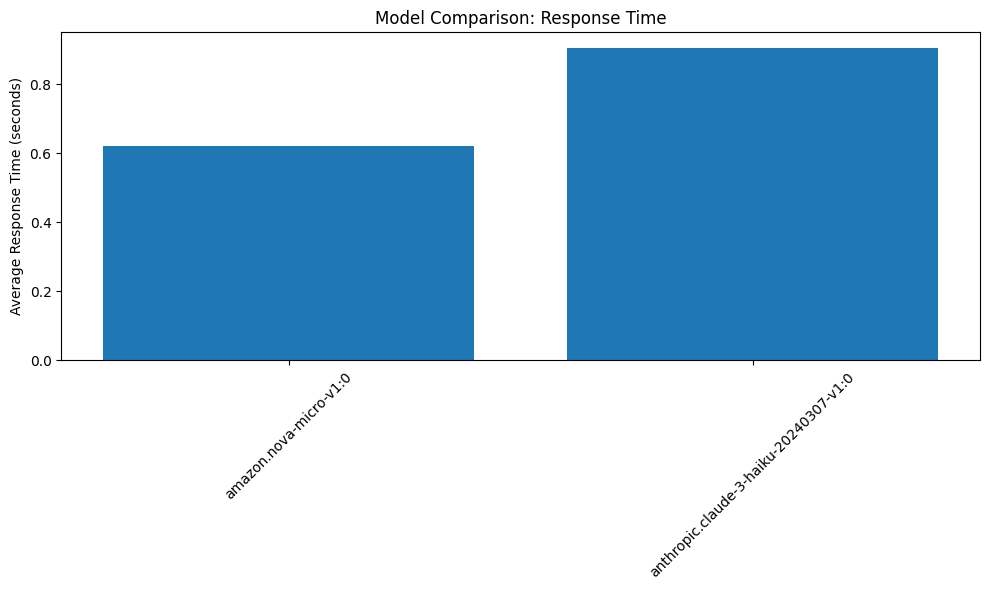


Sample response from amazon.nova-micro-v1:0:
Question: What is the capital of France?
Response: The capital of France is Paris. Paris is not only the capital city but also the most populous city in France. It is located in the northern central part of the country and is known for its significant cultural, political, and economic influence both within France and globally. Paris is famous for its landmarks such as the Eiffel Tower, the Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées, among other historic and modern attractions.

Sample response from anthropic.claude-3-haiku-20240307-v1:0:
Question: What is the capital of France?
Response: The capital of France is Paris.


In [47]:
# Visualize comparison results
if all_results:
    # Extract metrics for visualization
    model_names = list(all_results.keys())
    avg_times = [sum(r['Response Time'] for r in results) / len(results) for results in all_results.values()]
    
    # Plot response times
    plt.figure(figsize=(10, 6))
    plt.bar(model_names, avg_times)
    plt.ylabel('Average Response Time (seconds)')
    plt.title('Model Comparison: Response Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Show a response sample for each model
    for model, results in all_results.items():
        print(f"\nSample response from {model}:")
        print(f"Question: {results[0]['Question']}")
        print(f"Response: {results[0]['Response']}")

## 15. Ethical Considerations and Responsible Use

When working with LLMs through Amazon Bedrock, it's important to consider several ethical aspects:

1. **Bias and Fairness**: LLMs can inherit biases from their training data, potentially reinforcing stereotypes or producing unfair outcomes.

2. **Privacy Concerns**: Models might memorize and reproduce sensitive information from their training data.

3. **Misinformation**: LLMs can generate plausible-sounding but incorrect information.

4. **Energy Consumption**: Running inference on large models requires computational resources and energy.

5. **Appropriate Use Cases**: Consider whether an LLM is the appropriate tool for a given task.

### Mitigation Strategies:

- **Input Validation**: Implement validation checks on prompts
- **Output Filtering**: Apply post-processing to filter harmful content
- **User Feedback**: Collect and incorporate user feedback to improve model outputs
- **Transparency**: Be clear about model limitations and the AI-generated nature of content
- **Model Selection**: Choose the right model for your use case based on requirements and constraints

## 16. Conclusion and Best Practices

### Best Practices for Working with Amazon Bedrock

1. **Choose the Right Model**: Select models based on your specific needs, considering factors like performance, cost, and latency.

2. **Optimize Prompts**: Carefully design and test prompts to get the best results from the model.

3. **Set Appropriate Parameters**: Adjust temperature, max tokens, and other parameters based on your use case.

4. **Implement Safety Measures**: Add filters and validations for both inputs and outputs.

5. **Monitor Usage**: Track performance, costs, and user feedback to continuously improve your implementation.

6. **Handle Rate Limits**: Implement appropriate retry strategies and rate limiting to handle API limits.

7. **Set Clear Expectations**: Be transparent with users about model capabilities and limitations.

### Key Takeaways

- Amazon Bedrock provides access to powerful foundation models through the Converse API
- Understanding model parameters like temperature and top-p is crucial for controlling outputs
- Different models excel at different tasks, so choose the right model for your use case
- Ethical considerations and safeguards should be implemented for responsible use

## Resources

- [Amazon Bedrock Developer Guide](https://docs.aws.amazon.com/bedrock/)
- [Amazon Bedrock API Reference](https://docs.aws.amazon.com/bedrock/latest/APIReference/)
- [AWS SDK for Python (boto3) Documentation](https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/bedrock.html)
- [Amazon Bedrock Samples](https://github.com/aws-samples/amazon-bedrock-samples)